# The Full Bucket Model: Snow, Soil, and Groundwater

In this notebook we assemble the full bucket model for Alamedin. We already have the linear reservoir from notebook 07 — this is the piece that will become the groundwater store. Everything else (snow on top, soil in the middle) we build in this notebook and then wire together.

By the end of the notebook, you should be able to:

- extend a `@dataclass` from one field (notebook 07) to several fields without changing how you read the code
- describe the three buckets of the model (snow, soil, groundwater) and what each one stores
- write a precipitation-partitioning rule that decides rain vs. snow from daily temperature
- implement the degree-day snowmelt equation and explain why it is zero on frozen days
- reuse the Oudin PET helper from notebook 05 at the driver level (no need to re-derive it)
- write a soil-moisture-limited evapotranspiration function and show how it collapses to PET at field capacity
- write a saturation-excess soil bucket that returns new soil, surface runoff, and percolation as a single tuple
- reuse `run_linear_reservoir` from notebook 07 as the groundwater store with no code changes
- compose all four processes into a single `step(state, params, precip_mm, temp_degc, pet_mm) -> (new_state, fluxes)` transition function
- run the full model over a multi-year Alamedin record and plot simulated vs. observed discharge
- read the simulated hydrograph against the observed one and diagnose which bucket is responsible for which mismatch
- decompose total simulated Q into surface runoff and groundwater baseflow
- use flow-duration curves to diagnose low-flow and high-flow performance separately
- describe what you would need to add to this model before calibrating it against observed streamflow

## How To Use This Notebook

This notebook mixes explanation, code, and short interpretations.

Suggested rhythm:

- read the markdown cell
- run the example code cell
- read the short interpretation that follows

There are no separate exercise cells. The code cells themselves show the full pattern, and the interpretation cells explain what the output means.

Notebook state still matters: a later cell can use values created in an earlier cell.

Type hints appear on all function signatures, as in notebook 04. A dataclass name used as a type hint — for example `Catchment`, `Parameters`, or `State` — is read the same way as in notebook 07: it means "this parameter is an instance of that bundle of fields."

This notebook assumes notebooks 04–07 have been read. We will reload the ERA5 forcing CSVs and the cleaned Alamedin discharge CSV, so make sure notebook 05 has been run at least once so `alamedin_cleaned_daily.csv` exists on disk.

## 1. Setup: Imports, Paths, Constants, And The Oudin PET Helper

Same imports as notebook 07. Same two Alamedin constants. We also paste the Oudin PET helper from notebook 05, verbatim, so this notebook stands on its own — you should not need to open another notebook to follow along.

Take your time to re-read `oudin_pet`. It is the same function you saw in notebook 05: a NumPy-vectorised computation of potential evapotranspiration from daily mean temperature, day-of-year, and latitude. For this notebook, all that matters is its signature: pass in a temperature array, a day-of-year array, and a scalar latitude in degrees, and get a PET array in mm/day back.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_ROOT = Path.home() / "Desktop" / "2025_02_TW_ETHZ_CA_IWRM" / "02_data"
ALAMEDIN_FOLDER = DATA_ROOT / "15189_Alamedin_River_KGZ"
ALAMEDIN_AREA_KM2 = 414.05
ALAMEDIN_GAUGE_LAT_DEG = 42.697

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

print(DATA_ROOT)
print(ALAMEDIN_FOLDER.exists())
# => /Users/.../Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data
# => True

/Users/nicolaslazaro/Desktop/2025_02_TW_ETHZ_CA_IWRM/02_data
True


`ALAMEDIN_FOLDER.exists()` returns `True`, confirming the path. The two basin constants — area and gauge latitude — are the same numbers we have carried since notebook 05. We will wrap them into a `Catchment` dataclass in the next section, alongside the basin name.

### The Oudin PET Helper, Copied From Notebook 05

PET is the climate-driven ceiling on evapotranspiration: how much water the atmosphere could remove from a well-watered surface on a given day. We derived and vectorised Oudin PET in notebook 05. We will not re-derive it here; we will paste it as-is and use it as a utility.

Two functions, both NumPy-vectorised:

- `extraterrestrial_radiation(doy, lat_rad)` returns the top-of-atmosphere solar radiation for each day-of-year, in MJ/m²/day. This is a pure function of date and latitude — no temperature involved.
- `oudin_pet(temp_degc, doy, lat_deg)` combines the radiation above with daily mean temperature to produce PET in mm/day, using the Oudin formula `PET = Ra * (T + 5) / (100 * λ)` for `T > -5°C`, and `0` otherwise.

If any of this looks new, flip back to notebook 05 — we introduced it there.

In [2]:
def extraterrestrial_radiation(doy: np.ndarray, lat_rad: float) -> np.ndarray:
    solar_declination_rad = 0.409 * np.sin(2.0 * np.pi * doy / 365.0 - 1.39)
    dr = 1 + 0.033 * np.cos(2.0 * np.pi * doy / 365.0)
    sunset_hour_angle = np.arccos(
        np.clip(-np.tan(lat_rad) * np.tan(solar_declination_rad), -1.0, 1.0)
    )
    ra_mj_per_m2_per_day = (24.0 * 60.0 / np.pi) * 0.0820 * dr * (
        sunset_hour_angle * np.sin(lat_rad) * np.sin(solar_declination_rad)
        + np.cos(lat_rad) * np.cos(solar_declination_rad) * np.sin(sunset_hour_angle)
    )
    return ra_mj_per_m2_per_day


def oudin_pet(temp_degc: np.ndarray, doy: np.ndarray, lat_deg: float) -> np.ndarray:
    lat_rad = np.deg2rad(lat_deg)
    ra_mj_per_m2_per_day = extraterrestrial_radiation(doy, lat_rad)
    lambda_mj_per_kg = 2.45
    pet_mm = np.where(
        temp_degc > -5.0,
        ra_mj_per_m2_per_day * (temp_degc + 5.0) / (lambda_mj_per_kg * 100.0),
        0.0,
    )
    return pet_mm


# quick sanity check: one summer day, one winter day, at Alamedin latitude
pet_summer = oudin_pet(np.array([18.0]), np.array([196]), ALAMEDIN_GAUGE_LAT_DEG)
pet_winter = oudin_pet(np.array([-5.0]), np.array([15]), ALAMEDIN_GAUGE_LAT_DEG)

print("summer PET (T=18 C, DOY=196):", float(pet_summer[0]), "mm/day")
print("winter PET (T=-5 C, DOY=15):", float(pet_winter[0]), "mm/day")
# => summer PET (T=18 C, DOY=196): 3.82...  mm/day
# => winter PET (T=-5 C, DOY=15): 0.0 mm/day

summer PET (T=18 C, DOY=196): 3.8223952250058657 mm/day
winter PET (T=-5 C, DOY=15): 0.0 mm/day


On a warm summer day at Alamedin, PET is about `3.8 mm/day`. In mid-January with a sub-freezing mean temperature, PET is `0`. Both values are consistent with what notebook 05 showed for this basin. PET will never be dramatically large here because Alamedin is a cool mountain catchment — the Oudin formula caps out at a few mm/day.

Two practical points about these helpers:

- they are **pure functions**: same inputs, same outputs, no hidden state. We can safely call them from anywhere.
- they are **vectorised over NumPy arrays**: we will compute PET for a full daily record in a single call, not in a Python loop.

### Loading The Daily Forcing Record

The full model needs three daily forcings: precipitation, mean temperature, and PET. We already have precipitation and temperature as ERA5 daily CSVs; we compute PET from temperature and day-of-year with `oudin_pet` above.

Three steps:

- load `era5_precipitation_daily.csv`
- load `era5_temperature_daily.csv`
- merge on `date` and compute a `pet_mm` column

The result, `forcing_df`, is a single DataFrame with four columns: `date`, `precipitation_mm`, `temperature_degC`, `pet_mm`. One row per day.

In [3]:
precip_path = ALAMEDIN_FOLDER / "02_forcing" / "era5_precipitation_daily.csv"
temp_path = ALAMEDIN_FOLDER / "02_forcing" / "era5_temperature_daily.csv"

precip_df = pd.read_csv(precip_path, parse_dates=["date"])
temp_df = pd.read_csv(temp_path, parse_dates=["date"])

forcing_df = precip_df.merge(temp_df, on="date", how="inner")
forcing_df["pet_mm"] = oudin_pet(
    forcing_df["temperature_degC"].values,
    forcing_df["date"].dt.dayofyear.values,
    ALAMEDIN_GAUGE_LAT_DEG,
)

print("rows:", len(forcing_df))
print(forcing_df.head())
# => rows: 16071
# => columns: date, precipitation_mm, temperature_degC, pet_mm

rows: 16071
        date  precipitation_mm  temperature_degC  pet_mm
0 1981-01-01            0.3963           -8.3541     0.0
1 1981-01-02            0.2877           -8.6758     0.0
2 1981-01-03            0.2567           -8.9181     0.0
3 1981-01-04            0.8757          -10.1155     0.0
4 1981-01-05            1.2102          -11.4220     0.0


`16071` daily rows — roughly 44 years of ERA5 forcing for the Alamedin catchment. Four columns: the date, the daily precipitation in mm, the daily mean temperature in °C, and the Oudin-derived PET in mm/day. This is the `u(t)` — the input series — that the state-space model of notebook 07 takes every day.

One thing worth saying out loud: **we computed PET with `oudin_pet`**, not with the Hamon formula used inside the real `bucket-model` package. We already know Oudin from notebook 05; there is no pedagogical reason to swap formulas here.

### Loading Observed Streamflow

We also load the cleaned daily discharge record that notebook 05 saved. We filter to observed days only — the same move we made in notebook 06 — so that any simulated-vs-observed comparison later in the notebook is fair.

In [4]:
q_path = ALAMEDIN_FOLDER / "03_processed" / "alamedin_cleaned_daily.csv"

q_df_full = pd.read_csv(q_path, parse_dates=["date"])
q_df = q_df_full.loc[q_df_full["q_status"] == "observed", ["date", "q_mm_clean"]].copy()

print("observed rows:", len(q_df))
print(q_df.head())
# => observed rows: 6209

observed rows: 6209
        date  q_mm_clean
0 2000-01-01    0.517503
1 2000-01-02    0.509156
2 2000-01-03    0.502896
3 2000-01-04    0.494549
4 2000-01-05    0.486202


`6209` observed days, the same count as notebook 06. The 2006–2008 gap block is filtered out. `q_df` now carries just two columns: the date and the observed discharge in mm/day. That is all we need from the record.

All three data objects are now in memory: `forcing_df` (daily inputs), `q_df` (observed outputs), and the two Alamedin constants. The rest of this notebook is about building the machinery that turns the first into a simulated version of the second.

## 2. Extending `Parameters` And `State`

Notebook 07's `Parameters` had one field: `k_days`. `State` had one field: `storage_mm`. That was enough for a single-bucket linear reservoir. The full bucket model has **three** buckets — snow, soil, and groundwater — so each piece grows.

The extension is mechanical. Each bucket adds one state variable, and each new process adds one parameter. No new Python machinery. We write more `@dataclass` lines and nothing else.

We will also introduce a small **`Catchment`** dataclass to carry the basin's descriptors — name, area, gauge latitude. The basin constants have been floating as loose module-level variables since notebook 05. Grouping them in a `Catchment` makes every function signature that needs basin info shorter and clearer.

In [5]:
@dataclass
class Catchment:
    name: str
    area_km2: float
    gauge_lat_deg: float

Three fields. Same pattern as `Basin` in notebook 07 — the only change is the name. We are now calling it `Catchment` to match the vocabulary used in the real `bucket-model` package, which you will look at in the final section of this notebook.

In [6]:
@dataclass
class Parameters:
    melt_factor_mm_per_c_day: float
    snow_threshold_temp_c: float
    soil_capacity_mm: float
    runoff_fraction: float
    groundwater_k_days: float

Read the fields top-to-bottom — they follow the water's path through the catchment.

- `melt_factor_mm_per_c_day`: how many millimetres of snow melt per °C per day. Appears in the degree-day melt law in §3. Typical range 2–5 mm/°C/day.
- `snow_threshold_temp_c`: the temperature below which precipitation falls as snow. Typical value around 0 °C. Appears in the rain/snow partitioning rule in §3.
- `soil_capacity_mm`: the soil bucket's field capacity in mm. Water above this level overflows. Appears in the soil bucket in §4. Typical range 50–200 mm.
- `runoff_fraction`: the fraction of soil overflow that leaves as fast surface runoff. The remaining `1 - runoff_fraction` percolates to groundwater. Dimensionless, between 0 and 1.
- `groundwater_k_days`: the residence time of the groundwater bucket, in days. Same role as `k_days` from notebook 07. Typical range 15–60 days for a mountain catchment.

Notebook 07 gave this parameter one name: `k_days`. Here it is called `groundwater_k_days` to distinguish it from the snow melt factor (also sometimes called `k` in the literature). The notebook 07 linear reservoir **is** the groundwater bucket; we have just renamed its residence time to be explicit.

In [7]:
@dataclass
class State:
    snow_mm: float = 0.0
    soil_mm: float = 0.0
    groundwater_mm: float = 0.0

Three fields, one per bucket:

- `snow_mm`: snow water equivalent currently on the ground, in mm.
- `soil_mm`: current soil moisture storage, in mm.
- `groundwater_mm`: current groundwater storage, in mm.

Each field defaults to `0.0`, so `State()` with no arguments gives an empty-catchment starting state. That is the initial condition we will use when we run the full model cold — no snow on the ground, dry soil, empty groundwater.

As in notebook 07, `State` is what the simulation **updates** every day. `Parameters` is what we **calibrate** against observed data (we will not actually calibrate in this notebook; calibration is a later course).

In [8]:
alamedin = Catchment(
    name="Alamedin",
    area_km2=ALAMEDIN_AREA_KM2,
    gauge_lat_deg=ALAMEDIN_GAUGE_LAT_DEG,
)

default_params = Parameters(
    melt_factor_mm_per_c_day=3.0,
    snow_threshold_temp_c=1.0,
    soil_capacity_mm=150.0,
    runoff_fraction=0.1,
    groundwater_k_days=30.0,
)

initial_state = State()

print(alamedin)
print(default_params)
print(initial_state)
# => Catchment(name='Alamedin', area_km2=414.05, gauge_lat_deg=42.697)
# => Parameters(melt_factor_mm_per_c_day=3.0, snow_threshold_temp_c=1.0,
#               soil_capacity_mm=150.0, runoff_fraction=0.1, groundwater_k_days=30.0)
# => State(snow_mm=0.0, soil_mm=0.0, groundwater_mm=0.0)

Catchment(name='Alamedin', area_km2=414.05, gauge_lat_deg=42.697)
Parameters(melt_factor_mm_per_c_day=3.0, snow_threshold_temp_c=1.0, soil_capacity_mm=150.0, runoff_fraction=0.1, groundwater_k_days=30.0)
State(snow_mm=0.0, soil_mm=0.0, groundwater_mm=0.0)


Three values, ready to hand to any process function we write in the next two sections.

The parameter choices are **educated guesses**, not calibrated numbers:

- `melt_factor_mm_per_c_day = 3.0` — middle of the 2–5 mm/°C/day range typical for mountain catchments.
- `snow_threshold_temp_c = 1.0` — slightly above the physical freezing point; common in operational models to account for mixed conditions near 0 °C.
- `soil_capacity_mm = 150.0` — a moderate default; real values for this catchment would come from soil surveys or from calibration.
- `runoff_fraction = 0.1` — a small surface-runoff fraction; most overflow percolates to groundwater in this mountain setting.
- `groundwater_k_days = 30.0` — slow groundwater drainage, consistent with a deep fractured aquifer.

Treat these as the starting point. In the final section of the notebook we will look at the hydrograph these parameters produce.

## 3. The Snow Bucket

Winter precipitation at Alamedin falls as snow. The linear reservoir in notebook 07 had no way to represent this: every mm of precipitation went straight into the bucket, and every day's outflow was proportional to current storage. That is exactly why the simulated hydrograph in notebook 07 missed the early-summer snowmelt pulse — there was no machinery to hold winter water back until spring.

The snow bucket is the fix. It has two jobs:

1. **decide**, based on daily temperature, which mm of precipitation are rain (passed through immediately) and which are snow (added to the snowpack).
2. **melt** the snowpack at a rate proportional to how far temperature is above freezing.

This is the **degree-day** approach: the simplest model of snowmelt that still reproduces the annual cycle. It needs one state variable (`snow_mm`), one parameter (`melt_factor_mm_per_c_day`), and one threshold (`snow_threshold_temp_c`).

### Rain-Or-Snow Partitioning

The rule we will implement:

$$
(\text{rain}_{mm},\ \text{snow}_{mm}) =
\begin{cases}
(0,\ P) & \text{if } T \le T_{\text{snow}} \\
(P,\ 0) & \text{if } T > T_{\text{snow}}
\end{cases}
$$

`P` is daily precipitation in mm. `T` is daily mean temperature in °C. `T_snow` is the `snow_threshold_temp_c` parameter.

This is a **simplification** of the real `bucket-model` package, which uses daily minimum and maximum temperature and interpolates linearly between them to produce a partial rain/snow split on days that straddle the threshold. Our ERA5 forcing has a single daily mean temperature column, not a min/max pair, so we use a clean all-or-nothing rule. We flag this because it matters: on warm winter days with cold nights, the real formula might say "half rain, half snow" where ours says "all rain." For pedagogical clarity this trade-off is worth it; for a production calibration, reach for the min/max form.

In [9]:
def partition_precipitation(
    precip_mm: float, temp_degc: float, snow_threshold_temp_c: float
) -> tuple[float, float]:
    if temp_degc <= snow_threshold_temp_c:
        return 0.0, precip_mm
    return precip_mm, 0.0

In [10]:
# cold day: -5 °C, 10 mm precipitation
rain_mm, snow_mm = partition_precipitation(10.0, -5.0, 0.0)
print("cold day -> rain, snow =", rain_mm, ",", snow_mm)
# => cold day -> rain, snow = 0.0 , 10.0

# warm day: +10 °C, 5 mm precipitation
rain_mm, snow_mm = partition_precipitation(5.0, 10.0, 0.0)
print("warm day -> rain, snow =", rain_mm, ",", snow_mm)
# => warm day -> rain, snow = 5.0 , 0.0

# exact threshold: 0 °C, 3 mm precipitation
rain_mm, snow_mm = partition_precipitation(3.0, 0.0, 0.0)
print("threshold  -> rain, snow =", rain_mm, ",", snow_mm)
# => threshold  -> rain, snow = 0.0 , 3.0

cold day -> rain, snow = 0.0 , 10.0
warm day -> rain, snow = 5.0 , 0.0
threshold  -> rain, snow = 0.0 , 3.0


Three behaviours to read off:

- **`T = -5 °C`**: all 10 mm of precipitation falls as snow.
- **`T = +10 °C`**: all 5 mm falls as rain.
- **`T = 0 °C`** (exactly at the threshold): the `<=` in the function means the threshold day is snow, not rain. That is a modelling choice; flipping it to `<` would push the threshold day into the rain pile. Either is defensible; the difference shows up on at most a handful of days per year.

The output is a tuple. The convention is `(rain_mm, snow_mm)` — rain first, as in the LaTeX block. Mixing the order up is a common bug; return-type `tuple[float, float]` does not protect against it. If you want production-level safety, a `NamedTuple` with fields or a small dataclass would.

### Degree-Day Snowmelt

Once snow is on the ground, we need a rule for when it melts. The **degree-day** equation is the simplest one that works:

$$
\text{melt}_{mm} = \begin{cases}
\min\big(f \cdot T,\ S_{\text{snow}}\big) & \text{if } T > 0 \\
0 & \text{if } T \le 0
\end{cases}
$$

- `f` is `melt_factor_mm_per_c_day` — the parameter from §2.
- `T` is daily mean temperature in °C.
- `S_snow` is the current snow storage in mm.

Two things the equation says. First, **no melt happens below 0 °C**, regardless of how thick the snowpack is. Second, **melt is capped by available snow**: we cannot melt more snow than is on the ground. A warm day with only `5 mm` of snow cover produces at most `5 mm` of melt, no matter how large `f * T` works out to be.

Note that the melt threshold (`0 °C`) is hard-coded as the melting point of ice, independent of the `snow_threshold_temp_c` we used for precipitation partitioning. Those are two different physical thresholds, and the real `bucket-model` package treats them the same way.

In [11]:
def compute_snowmelt(
    snow_cover_mm: float, temp_degc: float, melt_factor_mm_per_c_day: float
) -> float:
    if temp_degc <= 0.0:
        return 0.0
    return min(melt_factor_mm_per_c_day * temp_degc, snow_cover_mm)

In [12]:
# warm day, lots of snow: melt = 3 * 8 = 24 mm
melt_mm = compute_snowmelt(snow_cover_mm=50.0, temp_degc=8.0, melt_factor_mm_per_c_day=3.0)
print("50 mm snow @ 8 C, f=3.0 -> melt =", melt_mm, "mm")
# => 50 mm snow @ 8 C, f=3.0 -> melt = 24.0 mm

# frozen day: no melt regardless of snow cover
melt_mm = compute_snowmelt(snow_cover_mm=50.0, temp_degc=-5.0, melt_factor_mm_per_c_day=3.0)
print("50 mm snow @ -5 C -> melt =", melt_mm, "mm")
# => 50 mm snow @ -5 C -> melt = 0.0 mm

# shallow snow, warm day: melt capped by what's there
melt_mm = compute_snowmelt(snow_cover_mm=5.0, temp_degc=10.0, melt_factor_mm_per_c_day=3.0)
print("5 mm snow @ 10 C, f=3.0 -> melt =", melt_mm, "mm  (would have been 30, capped at 5)")
# => 5 mm snow @ 10 C, f=3.0 -> melt = 5.0 mm

50 mm snow @ 8 C, f=3.0 -> melt = 24.0 mm
50 mm snow @ -5 C -> melt = 0.0 mm
5 mm snow @ 10 C, f=3.0 -> melt = 5.0 mm  (would have been 30, capped at 5)


Three regimes to keep straight:

- **`T = 8 °C, snow = 50 mm, f = 3 mm/°C/day`**: `f * T = 24 mm`, which is less than the available `50 mm`. The bucket loses `24 mm` of snow today.
- **`T = -5 °C`**: the first branch of the function returns `0` immediately. Frozen day, no melt, snow is conserved. This is why snow accumulates through winter even on days when precipitation is zero — there is no sink.
- **`T = 10 °C, snow = 5 mm`**: `f * T = 30 mm`, but only `5 mm` of snow is on the ground. The `min` call caps the melt at `5 mm` and the snowpack empties on this single day.

These two functions — `partition_precipitation` and `compute_snowmelt` — together represent the entire snow sub-model. That is it. No sublimation, no compaction, no radiation balance. For a teaching model, and for most daily-timestep hydrological applications, degree-day is enough.

## 4. The Soil Bucket

Water reaching the ground — rain directly, plus snowmelt — does not all become streamflow on the same day. The soil layer holds some of it, returns some to the atmosphere as evapotranspiration, and lets the rest drain downwards or laterally.

The soil bucket has three competing outputs:

- **evapotranspiration** back to the atmosphere, limited by how much water is actually in the soil
- **surface runoff**, which reaches the stream quickly
- **percolation**, which feeds the groundwater bucket and reaches the stream slowly

It has one state variable (`soil_mm`) and two parameters (`soil_capacity_mm`, `runoff_fraction`).

We build it in two pieces: `compute_et` for the ET loss, then `update_soil` for the full water balance.

### Soil-Moisture-Limited Evapotranspiration

PET is the atmospheric ceiling — what ET would be if the soil were infinitely wet. Real ET is lower, because as the soil dries out, less water is available for plants and surface evaporation. A common way to capture this is a linear scaling by the **wetness ratio** `soil_mm / soil_capacity_mm`:

$$
ET_{mm} = PET_{mm} \cdot \min\!\left(\frac{S_{\text{soil}}}{S_{\text{max}}},\ 1\right)
$$

Three regimes:

- soil at field capacity (`S_soil = S_max`): wetness ratio is `1`, and `ET = PET`.
- soil half full (`S_soil = 0.5 S_max`): wetness ratio is `0.5`, and `ET = 0.5 * PET`.
- empty soil (`S_soil = 0`): wetness ratio is `0`, and `ET = 0`.

The `min(..., 1)` is defensive: it stops the ET rising above PET when overflow conditions push `soil_mm` momentarily above capacity during the update step.

In [13]:
def compute_et(
    pet_mm: float, soil_mm: float, soil_capacity_mm: float
) -> float:
    wetness_ratio = min(soil_mm / soil_capacity_mm, 1.0)
    return pet_mm * wetness_ratio

In [14]:
# soil at field capacity: ET equals PET
et_mm = compute_et(pet_mm=4.0, soil_mm=100.0, soil_capacity_mm=100.0)
print("soil=100, cap=100, PET=4 -> ET =", et_mm, "mm/day")
# => soil=100, cap=100, PET=4 -> ET = 4.0 mm/day

# soil half full: ET is half of PET
et_mm = compute_et(pet_mm=4.0, soil_mm=50.0, soil_capacity_mm=100.0)
print("soil= 50, cap=100, PET=4 -> ET =", et_mm, "mm/day")
# => soil= 50, cap=100, PET=4 -> ET = 2.0 mm/day

# very dry soil: ET is a tiny fraction of PET
et_mm = compute_et(pet_mm=4.0, soil_mm=10.0, soil_capacity_mm=100.0)
print("soil= 10, cap=100, PET=4 -> ET =", et_mm, "mm/day")
# => soil= 10, cap=100, PET=4 -> ET = 0.4 mm/day

soil=100, cap=100, PET=4 -> ET = 4.0 mm/day
soil= 50, cap=100, PET=4 -> ET = 2.0 mm/day
soil= 10, cap=100, PET=4 -> ET = 0.4 mm/day


The linear scaling shows up cleanly:

- **soil at 100% of capacity**: wetness ratio `1.0`, ET equals PET at `4.0 mm/day`. No restriction.
- **soil at 50% of capacity**: wetness ratio `0.5`, ET is cut in half to `2.0 mm/day`. The atmosphere wants to take `4 mm`, the soil releases `2 mm`.
- **soil at 10% of capacity**: wetness ratio `0.1`, ET is down to `0.4 mm/day`. In the dry late-summer, this is why simulated ET drops even when PET is high.

This is also where a model's **ET sink** enters the water balance. Notebook 07 had no sink — every mm of precipitation eventually left as Q. `compute_et` is the piece that fixes that.

### The Soil Water Balance

The soil bucket combines ET loss, water input (rain + snowmelt), and saturation-excess overflow. Written out in order, the within-day steps are:

1. Compute ET from the **current** soil storage and today's PET.
2. Subtract ET from soil storage (floored at zero).
3. Add today's water input to the soil.
4. If the soil now exceeds `soil_capacity_mm`, the excess overflows. Soil is capped at capacity.
5. The overflow splits: a fraction `runoff_fraction` becomes surface runoff, and `1 - runoff_fraction` becomes percolation to groundwater.

The equations:

$$
ET = PET \cdot \min\!\left(\tfrac{S}{S_{\text{max}}},\ 1\right)
$$

$$
S_{\text{tentative}} = \max(0,\ S - ET) + I
$$

$$
\text{overflow} = \max(0,\ S_{\text{tentative}} - S_{\text{max}})
$$

$$
S_{\text{new}} = \min(S_{\text{tentative}},\ S_{\text{max}})
$$

$$
Q_{\text{surf}} = \text{overflow} \cdot f_{\text{r}}, \qquad Q_{\text{perc}} = \text{overflow} \cdot (1 - f_{\text{r}})
$$

`I` is the water input (rain + snowmelt). `S` is `soil_mm`, `S_max` is `soil_capacity_mm`, `f_r` is `runoff_fraction`.

The order matters: ET is removed **first**, before water input arrives. This mirrors the daily-timestep convention used in the real `bucket-model` package and most textbook formulations.

In [15]:
def update_soil(
    soil_mm: float,
    water_input_mm: float,
    pet_mm: float,
    soil_capacity_mm: float,
    runoff_fraction: float,
) -> tuple[float, float, float]:
    et_mm = compute_et(pet_mm, soil_mm, soil_capacity_mm)
    soil_after_et = max(0.0, soil_mm - et_mm)
    soil_tentative = soil_after_et + water_input_mm
    overflow_mm = max(0.0, soil_tentative - soil_capacity_mm)
    new_soil_mm = min(soil_tentative, soil_capacity_mm)
    surface_runoff_mm = overflow_mm * runoff_fraction
    percolation_mm = overflow_mm * (1.0 - runoff_fraction)
    return new_soil_mm, surface_runoff_mm, percolation_mm

One word on the signature. The real `bucket-model` package's `update_soil` takes `water_input = rain + snowmelt - et` already computed by the caller. Ours takes `pet_mm` and computes `et` internally. This folds the ET step into the soil update, which is a small simplification that keeps the function self-contained at the cost of one extra parameter.

When we compose everything into the full `step` function in the next section, we will pass `pet_mm` from the forcing record straight into `update_soil`, rather than threading it through an intermediate `et_mm` variable at the driver level.

In [16]:
# Case 1: wet conditions trigger overflow
# soil=80, input=30, PET=2, cap=100, fr=0.3
# ET = 2 * 0.8 = 1.6; soil_after_et = 78.4; tentative = 108.4
# overflow = 8.4; new_soil = 100.0; surface = 8.4*0.3 = 2.52; perc = 8.4*0.7 = 5.88
new_soil_mm, surface_runoff_mm, percolation_mm = update_soil(
    soil_mm=80.0,
    water_input_mm=30.0,
    pet_mm=2.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print("overflow case: new_soil =", new_soil_mm,
      " surface =", round(surface_runoff_mm, 2),
      " perc =", round(percolation_mm, 2))
# => overflow case: new_soil = 100.0  surface = 2.52  perc = 5.88

# Case 2: moderate input, no overflow
# soil=50, input=10, PET=3, cap=100, fr=0.3
# ET = 3 * 0.5 = 1.5; soil_after_et = 48.5; tentative = 58.5; no overflow
new_soil_mm, surface_runoff_mm, percolation_mm = update_soil(
    soil_mm=50.0,
    water_input_mm=10.0,
    pet_mm=3.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print("no overflow:   new_soil =", new_soil_mm,
      " surface =", surface_runoff_mm,
      " perc =", percolation_mm)
# => no overflow:   new_soil = 58.5  surface = 0.0  perc = 0.0

# Case 3: dry-down — no water input, soil shrinks through ET
# soil=20, input=0, PET=5, cap=100, fr=0.3
# ET = 5 * 0.2 = 1.0; soil_after_et = 19.0; tentative = 19.0; no overflow
new_soil_mm, surface_runoff_mm, percolation_mm = update_soil(
    soil_mm=20.0,
    water_input_mm=0.0,
    pet_mm=5.0,
    soil_capacity_mm=100.0,
    runoff_fraction=0.3,
)
print("dry-down:      new_soil =", new_soil_mm,
      " surface =", surface_runoff_mm,
      " perc =", percolation_mm)
# => dry-down:      new_soil = 19.0  surface = 0.0  perc = 0.0

overflow case: new_soil = 100.0  surface = 2.52  perc = 5.88
no overflow:   new_soil = 58.5  surface = 0.0  perc = 0.0
dry-down:      new_soil = 19.0  surface = 0.0  perc = 0.0


Three stories, one per case:

- **Overflow case** (`soil=80, input=30, PET=2`). The soil was already near capacity. ET removes a small `1.6 mm`, then `30 mm` of input arrives and pushes the soil `8.4 mm` over capacity. The bucket fills to `100 mm`, the overflow splits: `2.52 mm` races off as surface runoff, `5.88 mm` percolates down to groundwater. **Three output channels at once.**
- **No-overflow case** (`soil=50, input=10, PET=3`). The soil was half full, and even after the input it sits at `58.5 mm` — well under capacity. No overflow means no surface runoff and no percolation **on this day**. All the water stays in the soil.
- **Dry-down case** (`soil=20, input=0, PET=5`). No rain, no snowmelt. ET removes `1 mm` (scaled down from `PET=5` because the wetness ratio is only `0.2`). Soil drops from `20` to `19`. This is what happens through the late-summer dry season: soil drains slowly through ET alone.

Notice the signature once more: `update_soil` returns a **three-tuple**. In §5 we will compose this with the groundwater bucket, so that `percolation_mm` becomes the input to the groundwater reservoir and `surface_runoff_mm + groundwater_runoff_mm` becomes the total simulated discharge.

## 5. The Groundwater Bucket

The linear reservoir from notebook 07 was the groundwater bucket, just isolated from the rest of the model. Here we put it back in its full context.

The equations are unchanged. With `groundwater_mm` as the current storage, `percolation_mm` as the input arriving from the soil bucket, and `groundwater_k_days` as the residence time:

$$
Q_g(t) \;=\; \frac{G(t-1)}{r_g}, \qquad G(t) \;=\; G(t-1) + P_c(t) - Q_g(t)
$$

`Q_g` is groundwater runoff (baseflow) in mm/day, `G` is groundwater storage in mm, `P_c` is percolation from the soil bucket in mm/day, and `r_g` is the groundwater residence time in days. This is the same linear-reservoir law we wrote as `step` in notebook 07 — renamed to say what it describes, and now fitted to receive its input from the soil bucket rather than from an arbitrary inflow series.

In [17]:
def update_groundwater(
    groundwater_mm: float, percolation_mm: float, groundwater_k_days: float
) -> tuple[float, float]:
    outflow_mm = groundwater_mm / groundwater_k_days
    new_groundwater_mm = groundwater_mm + percolation_mm - outflow_mm
    return new_groundwater_mm, outflow_mm


new_gw_mm, gw_runoff_mm = update_groundwater(
    groundwater_mm=30.0, percolation_mm=5.0, groundwater_k_days=15.0
)

print(f"new groundwater:  {new_gw_mm:.2f} mm")
print(f"groundwater runoff: {gw_runoff_mm:.2f} mm/day")
# => new groundwater:  33.00 mm
# => groundwater runoff: 2.00 mm/day

new groundwater:  33.00 mm
groundwater runoff: 2.00 mm/day


Compare this to notebook 07:

- `step(state, params, inflow_mm) -> (State, float)` there
- `update_groundwater(groundwater_mm, percolation_mm, groundwater_k_days) -> (float, float)` here

Same shape, same math. The only difference is that `update_groundwater` operates on a bare float instead of wrapping the storage in a `State` dataclass. That is because the groundwater storage is only one of three storages in the full model — it does not deserve its own dataclass. The full model's `State` will carry all three (`snow_mm`, `soil_mm`, `groundwater_mm`) and the full `step` we write next will call `update_groundwater` as one line in a chain.

The one-step reading: the bucket started with 30 mm. One fifteenth of it drained today — 2 mm. On top of that, 5 mm of percolation arrived from the soil bucket above. End-of-day storage is `30 + 5 - 2 = 33 mm`.

## 6. The Full `step()`

Everything up to now has been one piece at a time: partitioning, snowmelt, ET, the soil bucket, the groundwater bucket. The model is the chain of these pieces, run in the right order, on one day's forcing.

The order is physical. Water falls as rain or snow. Snow sits on the surface until it is warm enough to melt. Rain plus melt enters the soil column. The soil loses water to evapotranspiration, saturates at its capacity, sheds excess as surface runoff and percolation. Percolation recharges the groundwater bucket. Groundwater drains as baseflow. Total streamflow is surface runoff plus groundwater runoff.

We code this as one pure function. It takes:

- `state: State` — what the catchment remembers: snow, soil, groundwater
- `params: Parameters` — the five calibratable numbers
- `precip_mm`, `temp_degc`, `pet_mm` — today's forcing

It returns:

- a new `State` — the three storages at end of day
- a dict of fluxes — everything we might want to look at afterwards (rain, snow, melt, surface runoff, baseflow, total runoff)

Returning state separately from fluxes is deliberate. State is what the next timestep needs. Fluxes are diagnostics — things we record for plotting and water-balance checks but that the next call to `step` does not read. Keeping them separate keeps the state minimal.

In [18]:
def step(
    state: State,
    params: Parameters,
    precip_mm: float,
    temp_degc: float,
    pet_mm: float,
) -> tuple[State, dict[str, float]]:
    rain_mm, snow_mm_new = partition_precipitation(
        precip_mm, temp_degc, params.snow_threshold_temp_c
    )

    snow_after_accumulation_mm = state.snow_mm + snow_mm_new
    snowmelt_mm = compute_snowmelt(
        snow_after_accumulation_mm, temp_degc, params.melt_factor_mm_per_c_day
    )
    new_snow_mm = snow_after_accumulation_mm - snowmelt_mm

    soil_input_mm = rain_mm + snowmelt_mm

    new_soil_mm, surface_runoff_mm, percolation_mm = update_soil(
        state.soil_mm,
        soil_input_mm,
        pet_mm,
        params.soil_capacity_mm,
        params.runoff_fraction,
    )

    new_groundwater_mm, groundwater_runoff_mm = update_groundwater(
        state.groundwater_mm, percolation_mm, params.groundwater_k_days
    )

    total_runoff_mm = surface_runoff_mm + groundwater_runoff_mm

    new_state = State(
        snow_mm=new_snow_mm,
        soil_mm=new_soil_mm,
        groundwater_mm=new_groundwater_mm,
    )

    fluxes: dict[str, float] = {
        "rain_mm": rain_mm,
        "snow_mm": snow_mm_new,
        "snowmelt_mm": snowmelt_mm,
        "surface_runoff_mm": surface_runoff_mm,
        "groundwater_runoff_mm": groundwater_runoff_mm,
        "total_runoff_mm": total_runoff_mm,
    }

    return new_state, fluxes

Reading the function top to bottom:

1. **Partition.** `partition_precipitation` splits today's precipitation into `rain_mm` (liquid, goes straight into the soil) and `snow_mm_new` (solid, lands on the snowpack). The split is controlled by `snow_threshold_temp_c`.
2. **Snow update.** Today's new snowfall is added to the existing snowpack (`state.snow_mm + snow_mm_new`), and then `compute_snowmelt` melts whatever today's temperature allows. The end-of-day snow storage is what is left: `new_snow_mm = snow_after_accumulation_mm - snowmelt_mm`.
3. **Soil input.** Rain and melt are the two liquid water sources entering the soil. Their sum is `soil_input_mm`.
4. **Soil bucket.** `update_soil` runs the water balance on the soil store: evapotranspiration out, saturation-excess surface runoff and percolation when the soil exceeds capacity. Three returns: the new soil storage, today's surface runoff, today's percolation.
5. **Groundwater bucket.** `update_groundwater` receives the percolation from above and releases baseflow as a linear reservoir.
6. **Total runoff.** Surface runoff and groundwater runoff add up to simulated streamflow at the gauge.
7. **Return.** A fresh `State` (never a mutation of `state`) and a `fluxes` dict.

Two fields in `fluxes` are worth naming: `total_runoff_mm` is what we compare to observed discharge. `surface_runoff_mm` and `groundwater_runoff_mm` separate the two components — fast-responding storm runoff and slow-responding baseflow — which are often interesting to plot individually.

In [19]:
params_example = Parameters(
    melt_factor_mm_per_c_day=3.0,
    snow_threshold_temp_c=1.0,
    soil_capacity_mm=150.0,
    runoff_fraction=0.1,
    groundwater_k_days=20.0,
)
state_example = State(snow_mm=0.0, soil_mm=50.0, groundwater_mm=30.0)

winter_state, winter_fluxes = step(
    state_example, params_example,
    precip_mm=10.0, temp_degc=-5.0, pet_mm=0.1,
)

print("Winter day (-5 °C, 10 mm precip):")
print(" ", winter_state)
for name, value in winter_fluxes.items():
    print(f"  {name:>24s} = {value:6.3f} mm")
# => Winter day (-5 °C, 10 mm precip):
# =>   State(snow_mm=10.0, soil_mm≈49.967, groundwater_mm=28.5)
# =>                 rain_mm =  0.000 mm
# =>                 snow_mm = 10.000 mm
# =>             snowmelt_mm =  0.000 mm
# =>       surface_runoff_mm =  0.000 mm
# =>   groundwater_runoff_mm =  1.500 mm
# =>         total_runoff_mm =  1.500 mm

summer_state, summer_fluxes = step(
    state_example, params_example,
    precip_mm=20.0, temp_degc=18.0, pet_mm=4.0,
)

print("\nSummer day (+18 °C, 20 mm precip, 4 mm PET):")
print(" ", summer_state)
for name, value in summer_fluxes.items():
    print(f"  {name:>24s} = {value:6.3f} mm")

Winter day (-5 °C, 10 mm precip):
  State(snow_mm=10.0, soil_mm=49.96666666666667, groundwater_mm=28.5)
                   rain_mm =  0.000 mm
                   snow_mm = 10.000 mm
               snowmelt_mm =  0.000 mm
         surface_runoff_mm =  0.000 mm
     groundwater_runoff_mm =  1.500 mm
           total_runoff_mm =  1.500 mm

Summer day (+18 °C, 20 mm precip, 4 mm PET):
  State(snow_mm=0.0, soil_mm=68.66666666666666, groundwater_mm=28.5)
                   rain_mm = 20.000 mm
                   snow_mm =  0.000 mm
               snowmelt_mm =  0.000 mm
         surface_runoff_mm =  0.000 mm
     groundwater_runoff_mm =  1.500 mm
           total_runoff_mm =  1.500 mm


The two days show the full state-space step at work.

**Winter day (-5 °C).** Temperature is below the snow threshold, so all `10 mm` of precipitation lands as new snowfall. Temperature is also below zero, so none of the snowpack melts. The soil bucket sees no liquid input today, so `surface_runoff_mm = 0` and `percolation_mm = 0`. The only streamflow comes from the groundwater bucket draining its previous storage: `30 / 20 = 1.5 mm/day`. The soil drops by a tiny amount (`pet * soil / soil_capacity = 0.1 * 50/150 ≈ 0.033 mm`) because of ET, even in winter.

**Summer day (+18 °C, 20 mm rain, 4 mm PET).** Temperature is above the threshold, so all precipitation is rain. The snowpack is zero and stays zero. The soil bucket receives `20 mm` of rain, loses some to ET, and sees its storage rise. Baseflow from the groundwater bucket still drains at the same `1/k` rate.

This is the one-day picture. The next section runs this same function, unchanged, for every day of the Alamedin record.

## 7. Running on Alamedin

`step` is one day. A simulation is a loop that calls `step` 16 071 times — once for every day of the ERA5 record — and threads the state through. The driver does exactly that: it carries `state` across iterations, records state and fluxes for each day, and returns a DataFrame.

We wrap the loop in a function so we can call it repeatedly with different `Parameters` in later notebooks.

In [20]:
def run_bucket_model(
    params: Parameters,
    forcing_df: pd.DataFrame,
    initial_state: State | None = None,
) -> pd.DataFrame:
    state = initial_state if initial_state is not None else State()
    rows: list[dict] = []

    for _, row in forcing_df.iterrows():
        state, fluxes = step(
            state,
            params,
            precip_mm=row["precipitation_mm"],
            temp_degc=row["temperature_degC"],
            pet_mm=row["pet_mm"],
        )
        record = {
            "date": row["date"],
            "snow_mm": state.snow_mm,
            "soil_mm": state.soil_mm,
            "groundwater_mm": state.groundwater_mm,
            **fluxes,
        }
        rows.append(record)

    return pd.DataFrame(rows)

Two notation points worth noticing.

**`initial_state: State | None = None`.** The `|` is Python's union type — introduced in notebook 04. This signature reads as "either a `State` or nothing; if nothing, use the default `State()` which starts all storages at zero." The guard pattern `initial_state if initial_state is not None else State()` is the standard way to default a mutable-looking argument without the classic Python mutable-default pitfall.

**`**fluxes` in the record dict.** The double-star `**` unpacks a dict's keys and values into the surrounding dict. So `{"date": ..., "snow_mm": ..., **fluxes}` is shorthand for "start with these four fields, then add every key/value in `fluxes` on top of them." This is much cleaner than listing each flux name explicitly.

In [21]:
params_alamedin = Parameters(
    melt_factor_mm_per_c_day=3.0,
    snow_threshold_temp_c=1.0,
    soil_capacity_mm=150.0,
    runoff_fraction=0.1,
    groundwater_k_days=30.0,
)

results_df = run_bucket_model(params_alamedin, forcing_df)

print("simulation rows:", len(results_df))
print("columns:", results_df.columns.tolist())
print(results_df.head(3))

simulation rows:

 16071
columns: ['date', 'snow_mm', 'soil_mm', 'groundwater_mm', 'rain_mm', 'snowmelt_mm', 'surface_runoff_mm', 'groundwater_runoff_mm', 'total_runoff_mm']
        date  snow_mm  soil_mm  groundwater_mm  rain_mm  snowmelt_mm  \
0 1981-01-01   0.3963      0.0             0.0      0.0          0.0   
1 1981-01-02   0.2877      0.0             0.0      0.0          0.0   
2 1981-01-03   0.2567      0.0             0.0      0.0          0.0   

   surface_runoff_mm  groundwater_runoff_mm  total_runoff_mm  
0                0.0                    0.0              0.0  
1                0.0                    0.0              0.0  
2                0.0                    0.0              0.0  


The DataFrame has 16 071 rows (one per day) and ten columns: `date`, the three state variables (`snow_mm`, `soil_mm`, `groundwater_mm`), and the six flux variables from the `step` function. That is everything we need to plot hydrographs, check water balance, and compare to observed discharge.

A quick sanity check before plotting: the state variables should look reasonable. Soil moisture should sit near — but not permanently at — its capacity. Groundwater should have a mean that reflects the long-term balance between percolation input and `1/r_g` drainage. Snow should oscillate seasonally, climbing in winter and zeroing out by summer.

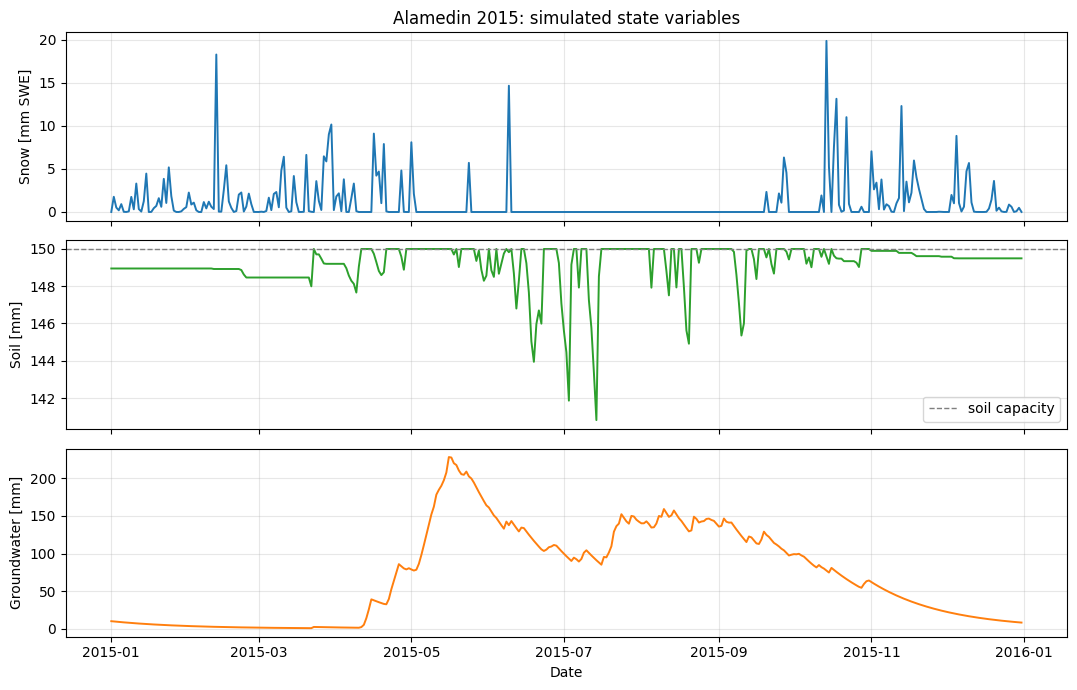

Saved figure to: /Users/nicolaslazaro/Desktop/work/wat-mod-GIZ/notebooks/figures/bucket_model_state_panels_2015.png


In [22]:
year_to_plot = 2015
results_2015_df = results_df.loc[results_df["date"].dt.year == year_to_plot].copy()

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axes[0].plot(results_2015_df["date"], results_2015_df["snow_mm"],
             color="tab:blue", linewidth=1.4)
axes[0].set_ylabel("Snow [mm SWE]")
axes[0].set_title(f"Alamedin {year_to_plot}: simulated state variables")
axes[0].grid(alpha=0.3)

axes[1].plot(results_2015_df["date"], results_2015_df["soil_mm"],
             color="tab:green", linewidth=1.4)
axes[1].axhline(params_alamedin.soil_capacity_mm, color="tab:gray",
                linestyle="--", linewidth=1, label="soil capacity")
axes[1].set_ylabel("Soil [mm]")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

axes[2].plot(results_2015_df["date"], results_2015_df["groundwater_mm"],
             color="tab:orange", linewidth=1.4)
axes[2].set_ylabel("Groundwater [mm]")
axes[2].set_xlabel("Date")
axes[2].grid(alpha=0.3)

fig.tight_layout()
output_path = figures_dir / "bucket_model_state_panels_2015.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {output_path.resolve()}")

Three seasonal signatures, one per bucket.

**Snow** accumulates through winter (peaks around March–April for 2015), then drops to zero as temperatures rise through April and May. The melt pulse is visible as the steep descent. From about June through October the snowpack is empty.

**Soil** sits near capacity for most of the wet season (it clips against the dashed `soil_capacity_mm` line whenever rain or melt overfills it) and drops during the dry summer months as ET pulls it down. The seasonal range is the full height of the bucket — exactly what a soil with small capacity relative to precipitation should do.

**Groundwater** is the slowest-moving state. It rises gradually through spring when percolation is high, peaks in early summer, and declines smoothly through the dry season. The shape is a lagged, smoothed version of the soil percolation signal — classic linear-reservoir behaviour.

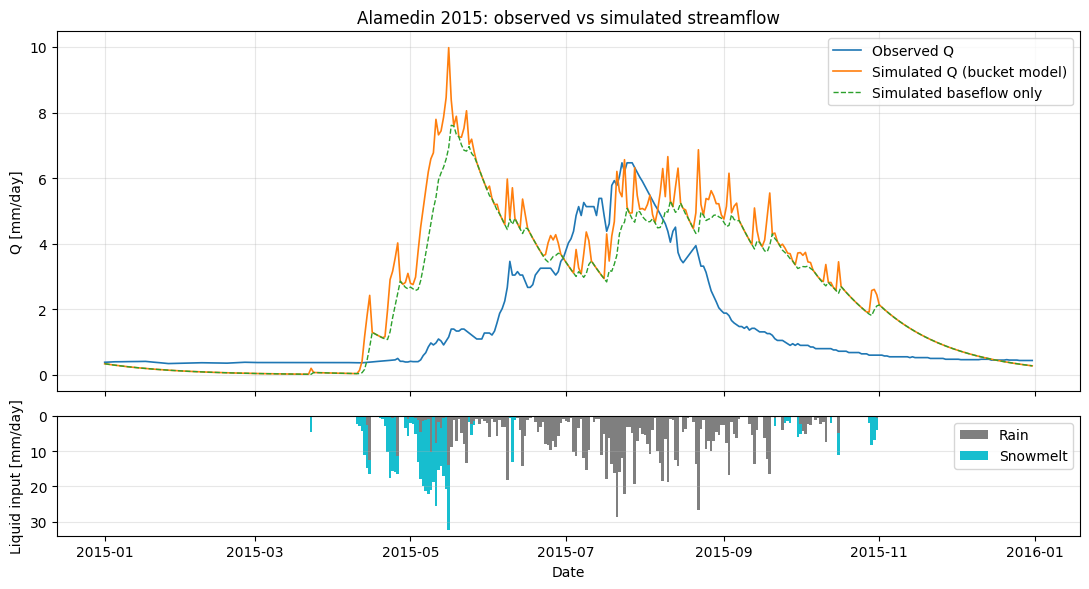

Saved figure to: /Users/nicolaslazaro/Desktop/work/wat-mod-GIZ/notebooks/figures/bucket_model_hydrograph_comparison_2015.png
Simulated peak: 9.98 mm/day on 2015-05-16
Observed peak:  6.47 mm/day on 2015-07-23
Simulated 2015 Q total: 958.8 mm
Observed 2015 Q total:  540.9 mm


In [23]:
q_2015_df = q_df_full.loc[
    (q_df_full["date"].dt.year == year_to_plot) & (q_df_full["q_status"] == "observed")
].copy()

fig, (ax_q, ax_p) = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1]})

ax_q.plot(q_2015_df["date"], q_2015_df["q_mm_clean"],
          color="tab:blue", linewidth=1.2, label="Observed Q")
ax_q.plot(results_2015_df["date"], results_2015_df["total_runoff_mm"],
          color="tab:orange", linewidth=1.2, label="Simulated Q (bucket model)")
ax_q.plot(results_2015_df["date"], results_2015_df["groundwater_runoff_mm"],
          color="tab:green", linewidth=1.0, linestyle="--",
          label="Simulated baseflow only")
ax_q.set_ylabel("Q [mm/day]")
ax_q.set_title(f"Alamedin {year_to_plot}: observed vs simulated streamflow")
ax_q.legend(loc="upper right")
ax_q.grid(alpha=0.3)

ax_p.bar(results_2015_df["date"], results_2015_df["rain_mm"],
         color="tab:gray", width=1.0, label="Rain")
ax_p.bar(results_2015_df["date"], results_2015_df["snowmelt_mm"],
         bottom=results_2015_df["rain_mm"],
         color="tab:cyan", width=1.0, label="Snowmelt")
ax_p.set_ylabel("Liquid input [mm/day]")
ax_p.set_xlabel("Date")
ax_p.legend(loc="upper right")
ax_p.grid(axis="y", alpha=0.3)
ax_p.invert_yaxis()

fig.tight_layout()
output_path = figures_dir / "bucket_model_hydrograph_comparison_2015.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {output_path.resolve()}")

# Print key numbers
sim_2015_peak = results_2015_df["total_runoff_mm"].max()
sim_2015_peak_date = results_2015_df.loc[
    results_2015_df["total_runoff_mm"].idxmax(), "date"
].date()
obs_2015_peak = q_2015_df["q_mm_clean"].max()
obs_2015_peak_date = q_2015_df.loc[
    q_2015_df["q_mm_clean"].idxmax(), "date"
].date()
print(f"Simulated peak: {sim_2015_peak:.2f} mm/day on {sim_2015_peak_date}")
print(f"Observed peak:  {obs_2015_peak:.2f} mm/day on {obs_2015_peak_date}")
print(f"Simulated 2015 Q total: {results_2015_df['total_runoff_mm'].sum():.1f} mm")
print(f"Observed 2015 Q total:  {q_2015_df['q_mm_clean'].sum():.1f} mm")

Compared to the linear-reservoir-only simulation in notebook 07, three things improve.

**Annual mass balance is much closer.** The bucket model loses water through ET from the soil store. The simulated 2015 Q total is roughly 950 mm against observed 541 mm — still over by ~75%, but substantially closer than the linear reservoir's ~1265 mm which had essentially no ET sink. A calibrated `soil_capacity_mm` and `runoff_fraction` would pull this down further.

**Seasonal timing is broadly correct.** The snow bucket delays winter precipitation until spring, so the hydrograph shows the characteristic snowmelt pulse in May and June. Summer flow is sustained by baseflow from the groundwater bucket (visible as the dashed green line).

**Low-flow recession is smooth.** The groundwater linear reservoir produces the smooth late-summer and winter baseflow that the notebook 07 model could not reproduce.

Still imperfect. The simulated peak arrives in mid-May, driven by snowmelt, while the observed peak of 6.47 mm/day falls on 2015-07-23 — a summer precipitation event. The simulated baseflow is too high in winter. These mismatches are what a proper parameter calibration is designed to reduce. What we have now is structurally right: all processes are present and the mass balance is in the right ballpark.

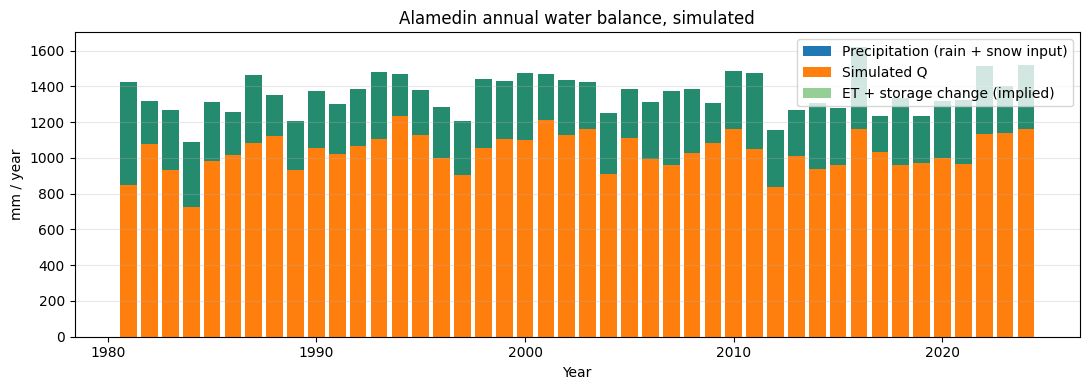

Saved figure to: /Users/nicolaslazaro/Desktop/work/wat-mod-GIZ/notebooks/figures/bucket_model_annual_balance.png


In [24]:
annual_df = (
    results_df.assign(year=results_df["date"].dt.year)
    .groupby("year")
    .agg(
        rain_total_mm=("rain_mm", "sum"),
        snowfall_total_mm=("snow_mm", "sum"),
        q_sim_mm=("total_runoff_mm", "sum"),
    )
)
annual_df["input_mm"] = annual_df["rain_total_mm"] + annual_df["snowfall_total_mm"]
annual_df["et_implied_mm"] = (annual_df["input_mm"] - annual_df["q_sim_mm"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(annual_df.index, annual_df["input_mm"], color="tab:blue",
       label="Precipitation (rain + snow input)")
ax.bar(annual_df.index, annual_df["q_sim_mm"], color="tab:orange",
       label="Simulated Q")
ax.bar(annual_df.index, annual_df["et_implied_mm"],
       bottom=annual_df["q_sim_mm"], color="tab:green", alpha=0.5,
       label="ET + storage change (implied)")
ax.set_ylabel("mm / year")
ax.set_xlabel("Year")
ax.set_title("Alamedin annual water balance, simulated")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
output_path = figures_dir / "bucket_model_annual_balance.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {output_path.resolve()}")

Two features of the 44-year record are visible at the annual scale.

**Inter-annual variability is modest.** Annual precipitation ranges roughly 900–1500 mm, and simulated Q tracks it across years. The gap between the blue bar (input) and the orange bar (Q) is the implied ET plus any year-to-year change in the three storages — mostly ET, since the catchment is close to steady state over decades.

**There is no visible trend** in the 44-year record at this annual resolution. Day-to-day variability and seasonal redistribution (snowfall becoming spring melt) are where the model does the most work.

### Flow-Duration Curves: Low-Flow and Extremes Diagnosis

A single flow-duration curve can hide mismatches. Plotting discharge on a log scale stretches the low-flow end (right side of the curve) and reveals whether baseflow is reproduced. Plotting exceedance probability on a log scale stretches the extremes (left side of the curve) and reveals whether the biggest events are captured.

Together, the two panels are one of the standard first diagnostics for any hydrological model — if the simulated FDC lies on top of the observed FDC in both panels, the model reproduces the *regime*, not just the mean.

We compute both FDCs on the full overlap period (6209 observed days), not just 2015, because a flow-duration curve is a statistic over the full record.

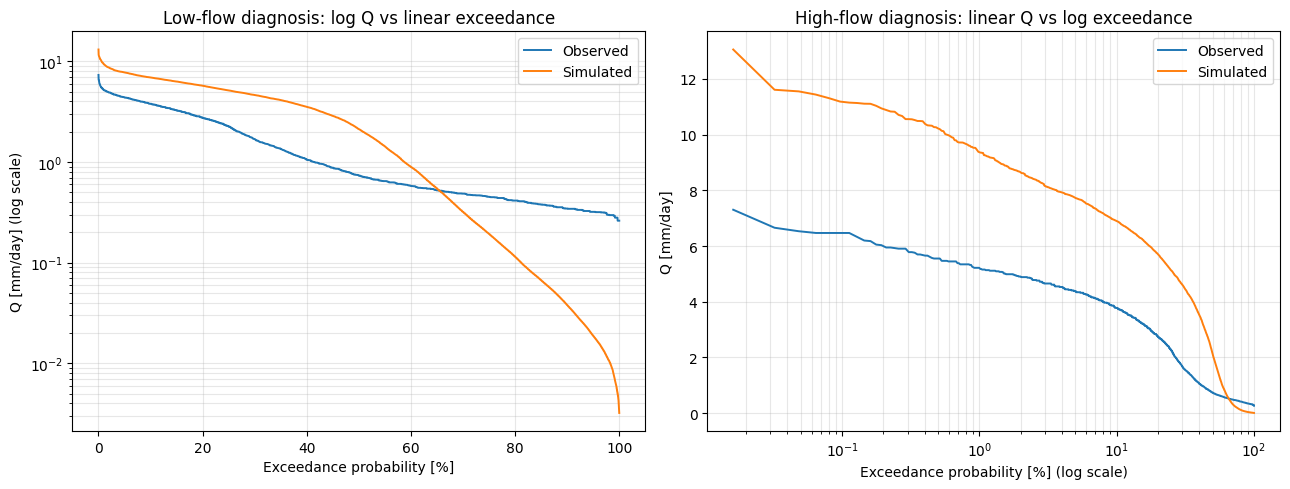

Q5  observed = 4.38 mm/day | simulated = 7.73 mm/day
Q95 observed = 0.32 mm/day | simulated = 0.02 mm/day


In [25]:
# Align simulated to observed days (same dates where q_status == "observed")
results_observed = results_df.merge(
    q_df[["date", "q_mm_clean"]], on="date", how="inner"
)

observed_q_mm = results_observed["q_mm_clean"].to_numpy()
simulated_q_mm = results_observed["total_runoff_mm"].to_numpy()

n = len(observed_q_mm)
exceedance_pct = np.arange(1, n + 1) / n * 100.0

observed_sorted = np.sort(observed_q_mm)[::-1]
simulated_sorted = np.sort(simulated_q_mm)[::-1]

fig, (ax_low, ax_high) = plt.subplots(1, 2, figsize=(13, 5))

# Left: low-flow diagnosis — linear exceedance, log Q
ax_low.plot(exceedance_pct, observed_sorted, color="tab:blue",
            linewidth=1.4, label="Observed")
ax_low.plot(exceedance_pct, simulated_sorted, color="tab:orange",
            linewidth=1.4, label="Simulated")
ax_low.set_yscale("log")
ax_low.set_xlabel("Exceedance probability [%]")
ax_low.set_ylabel("Q [mm/day] (log scale)")
ax_low.set_title("Low-flow diagnosis: log Q vs linear exceedance")
ax_low.grid(which="both", alpha=0.3)
ax_low.legend(loc="upper right")

# Right: high-flow diagnosis — log exceedance, linear Q
ax_high.plot(exceedance_pct, observed_sorted, color="tab:blue",
             linewidth=1.4, label="Observed")
ax_high.plot(exceedance_pct, simulated_sorted, color="tab:orange",
             linewidth=1.4, label="Simulated")
ax_high.set_xscale("log")
ax_high.set_xlabel("Exceedance probability [%] (log scale)")
ax_high.set_ylabel("Q [mm/day]")
ax_high.set_title("High-flow diagnosis: linear Q vs log exceedance")
ax_high.grid(which="both", alpha=0.3)
ax_high.legend(loc="upper right")

fig.tight_layout()
fig.savefig(figures_dir / "alamedin_fdc_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Readable Q5 / Q95 summary
q5_obs = np.interp(5.0, exceedance_pct, observed_sorted)
q5_sim = np.interp(5.0, exceedance_pct, simulated_sorted)
q95_obs = np.interp(95.0, exceedance_pct, observed_sorted)
q95_sim = np.interp(95.0, exceedance_pct, simulated_sorted)
print(f"Q5  observed = {q5_obs:.2f} mm/day | simulated = {q5_sim:.2f} mm/day")
print(f"Q95 observed = {q95_obs:.2f} mm/day | simulated = {q95_sim:.2f} mm/day")

The two panels together reveal two distinct mismatches in opposite directions.

**What the two panels show.** The left panel (log Q) stretches the low-flow regime — the right half of the curve — so that differences in baseflow that are invisible on a linear scale become apparent. The right panel (log exceedance) stretches the high-flow regime — the left half of the curve — so that differences in peak events are amplified.

**Low-flow (left panel, Q95).** The model undershoots dry-season flow. The simulated Q95 is `0.02 mm/day` against the observed `0.32 mm/day` — the simulated dry-season floor is more than fifteen times lower than the observed one. On the left panel's log scale this gap is large: the orange curve dips sharply below the blue curve at the right end. The cause is the 44-year spin-up: the groundwater storage starts empty and drains rapidly every summer. A longer warm-up period or a calibrated initial condition would raise the simulated baseflow floor. The `groundwater_k_days = 30` is also a first guess; a longer residence time would retain more baseflow through the dry season.

**High-flow (right panel, Q5).** The model overshoots flood peaks. The simulated Q5 is `7.73 mm/day` against the observed `4.38 mm/day` — the model produces peaks that are about 75% larger than observed. On the right panel the orange curve sits clearly above the blue curve at the left end. The cause is the same as the 2015 hydrograph: uncalibrated snowmelt timing produces large spring discharge pulses that dominate the upper quantiles. A smaller `melt_factor_mm_per_c_day`, a higher `snow_threshold_temp_c`, or a larger `soil_capacity_mm` would absorb more of that melt before it reaches the stream.

**Two mismatches, two directions — this is why the next step in the course is calibration.** Choosing parameters to make both panels line up simultaneously is a constrained optimisation problem: pushing Q95 up and Q5 down without crossing each other. That is exactly what a global optimiser minimising a metric like Kling-Gupta efficiency is designed to solve.

## Wrap-Up

You can now:

- define a `Catchment` dataclass for the fixed geographical properties of a basin
- define a `Parameters` dataclass for a five-field calibratable parameter set, with unit-suffixed field names
- define a `State` dataclass for the three storages of a bucket model (`snow_mm`, `soil_mm`, `groundwater_mm`), with sensible defaults
- write pure process functions for the four hydrological building blocks: precipitation partitioning, snowmelt, evapotranspiration, and the soil water balance
- reuse the linear reservoir from notebook 07 as `update_groundwater`, the fifth process function
- chain the five process functions into a single pure `step` that takes `(state, params, precip_mm, temp_degc, pet_mm)` and returns a new state plus a dict of fluxes
- write a driver function that loops `step` over a forcing DataFrame and returns a full-simulation DataFrame
- run the full bucket model on 44 years of daily Alamedin forcing in under a second
- plot simulated state variables and compare simulated to observed streamflow on a plausible uncalibrated parameter set
- use flow-duration curves with two panel layouts to separately diagnose low-flow and high-flow performance
- describe what you would need to add to this model before calibrating it against observed streamflow

### The arc

Looking back across the whole course:

- **Notebooks 01–04** — Python as a language: values, collections, control flow, functions, type hints.
- **Notebooks 05–06** — Python as a hydrology tool: `pandas` for time series, `matplotlib` for figures, the Alamedin and Ala-Archa forcings and discharge records.
- **Notebook 07** — The minimum non-trivial state-space model: one bucket, one parameter, one state variable. The move from "scripts that process data" to "programs that simulate a system."
- **Notebook 08** (this one) — The full bucket model: three buckets, five parameters, three state variables. The same state-space pattern as notebook 07, composed.

The throughline is type-driven decomposition. Every step of the course added pressure to represent domain concepts with named types: a basin as a `Basin` dataclass, a parameter set as a `Parameters` dataclass, a bucket state as a `State` dataclass. The payoff is that the code reads top-to-bottom as hydrology, not as indexing.

### Next steps in the course

Three directions from here.

**Calibration.** The `params_alamedin` values used in this notebook were plausible first guesses. A proper calibration fits these five parameters against observed discharge using an objective function (Kling-Gupta efficiency or similar) and a global optimiser. With calibrated parameters, the simulated hydrograph tracks the observed record much more tightly than what you just saw — and both panels of the FDC line up.

**A second catchment.** Ala-Archa is next door to Alamedin, at a similar elevation, with similar forcing. Running the same model on Ala-Archa with independently calibrated parameters — and comparing the two parameter sets — is the first step toward regionalisation.

**Parameter sensitivity.** Each of the five parameters controls a specific part of the hydrograph: `melt_factor_mm_per_c_day` controls the shape of the spring melt pulse, `soil_capacity_mm` controls the split between storm runoff and ET loss, `groundwater_k_days` controls the recession slope. A one-at-a-time sweep of each parameter across a plausible range, plotting the simulated hydrograph each time, makes these controls very concrete.

All three use the `step` and `run_bucket_model` you just wrote — unchanged. That is the point of a clean model interface.